In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("Churn_Modelling_NEW.csv")
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1.0,15634602,Hargrave,619.0,France,Female,42,2.0,0.00,1.0,1,1.0,101348.88,1.0
1,2.0,15647311,Hill,608.0,Spain,Female,41,1.0,83807.86,1.0,0,1.0,112542.58,0.0
2,3.0,15619304,Onio,502.0,France,Female,42,8.0,159660.80,3.0,1,0.0,113931.57,1.0
3,4.0,15701354,Boni,699.0,France,Female,39,1.0,0.00,2.0,0,0.0,93826.63,0.0
4,5.0,15737888,Mitchell,850.0,Spain,Female,43,2.0,125510.82,1.0,1,1.0,79084.10,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996.0,15606229,Obijiaku,771.0,France,Male,39,5.0,0.00,2.0,1,0.0,96270.64,0.0
9996,9997.0,15569892,Johnstone,516.0,France,Male,35,10.0,57369.61,1.0,1,1.0,101699.77,0.0
9997,9998.0,15584532,Liu,709.0,France,Female,36,7.0,0.00,1.0,0,1.0,42085.58,1.0
9998,9999.0,15682355,Sabbatini,772.0,Germany,Male,42,3.0,75075.31,2.0,1,0.0,92888.52,1.0


In [3]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1.0,15634602,Hargrave,619.0,France,Female,42,2.0,0.00,1.0,1,1.0,101348.88,1.0
1,2.0,15647311,Hill,608.0,Spain,Female,41,1.0,83807.86,1.0,0,1.0,112542.58,0.0
2,3.0,15619304,Onio,502.0,France,Female,42,8.0,159660.80,3.0,1,0.0,113931.57,1.0
3,4.0,15701354,Boni,699.0,France,Female,39,1.0,0.00,2.0,0,0.0,93826.63,0.0
4,5.0,15737888,Mitchell,850.0,Spain,Female,43,2.0,125510.82,1.0,1,1.0,79084.10,0.0


In [4]:
df.shape

(10000, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        9998 non-null   float64
 1   CustomerId       10000 non-null  int64  
 2   Surname          9994 non-null   object 
 3   CreditScore      9999 non-null   float64
 4   Geography        9999 non-null   object 
 5   Gender           9996 non-null   object 
 6   Age              10000 non-null  int64  
 7   Tenure           9999 non-null   float64
 8   Balance          9998 non-null   float64
 9   NumOfProducts    9999 non-null   float64
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   9999 non-null   float64
 12  EstimatedSalary  9998 non-null   float64
 13  Exited           9998 non-null   float64
dtypes: float64(8), int64(3), object(3)
memory usage: 1.1+ MB


In [6]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,9998.000000,1.000000e+04,9999.000000,10000.000000,9999.000000,9998.000000,9999.000000,10000.00000,9999.000000,9998.000000,9998.000000
mean,4999.800560,1.569094e+07,650.544454,38.921800,5.013001,76489.714055,1.530153,0.70550,0.515052,100087.837136,0.203741
std,2886.760758,7.193619e+04,96.645453,10.487806,2.892249,62397.785049,0.581664,0.45584,0.499798,57514.143519,0.402799
min,1.000000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.250000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,50983.750000,0.000000
50%,4999.500000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7498.750000,1.575323e+07,718.000000,44.000000,7.000000,127647.840000,2.000000,1.00000,1.000000,149395.882500,0.000000
max,10000.000000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [7]:
df.size

140000

In [8]:
df.isnull()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9996,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9997,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9998,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [9]:
df.isnull().sum()

RowNumber          2
CustomerId         0
Surname            6
CreditScore        1
Geography          1
Gender             4
Age                0
Tenure             1
Balance            2
NumOfProducts      1
HasCrCard          0
IsActiveMember     1
EstimatedSalary    2
Exited             2
dtype: int64

In [10]:
df[df["RowNumber"].isnull()==True]

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
8492,NaN,15804104,Romani,NaN,France,Male,28,9.0,NaN,2.0,0,1.0,NaN,0.0
8500,NaN,15584785,NaN,660.0,France,NaN,37,2.0,97324.91,1.0,1,0.0,23291.83,0.0


In [11]:
df.iloc[8492,2] = "RAM"

In [12]:
df[df["RowNumber"].isnull()==True]

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
8492,NaN,15804104,RAM,NaN,France,Male,28,9.0,NaN,2.0,0,1.0,NaN,0.0
8500,NaN,15584785,NaN,660.0,France,NaN,37,2.0,97324.91,1.0,1,0.0,23291.83,0.0


In [13]:
df.iloc[8492,0] = 8593
df.iloc[8500,0] = 8501

In [14]:
df.iloc[8492],df.iloc[8500]

(RowNumber            8593.0
 CustomerId         15804104
 Surname                 RAM
 CreditScore             NaN
 Geography            France
 Gender                 Male
 Age                      28
 Tenure                  9.0
 Balance                 NaN
 NumOfProducts           2.0
 HasCrCard                 0
 IsActiveMember          1.0
 EstimatedSalary         NaN
 Exited                  0.0
 Name: 8492, dtype: object,
 RowNumber            8501.0
 CustomerId         15584785
 Surname                 NaN
 CreditScore           660.0
 Geography            France
 Gender                  NaN
 Age                      37
 Tenure                  2.0
 Balance            97324.91
 NumOfProducts           1.0
 HasCrCard                 1
 IsActiveMember          0.0
 EstimatedSalary    23291.83
 Exited                  0.0
 Name: 8500, dtype: object)

In [15]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            6
CreditScore        1
Geography          1
Gender             4
Age                0
Tenure             1
Balance            2
NumOfProducts      1
HasCrCard          0
IsActiveMember     1
EstimatedSalary    2
Exited             2
dtype: int64

In [16]:
df["Geography"].value_counts()

Geography
France     5014
Germany    2509
Spain      2476
Name: count, dtype: int64

In [17]:
df["Geography"].mode()

0    France
Name: Geography, dtype: object

In [18]:
df["Geography"].mode()[0]

'France'

In [19]:
df["Geography"].fillna(df["Geography"].mode()[0],inplace=True)

In [20]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            6
CreditScore        1
Geography          0
Gender             4
Age                0
Tenure             1
Balance            2
NumOfProducts      1
HasCrCard          0
IsActiveMember     1
EstimatedSalary    2
Exited             2
dtype: int64

In [21]:
df["Gender"].value_counts()

Gender
Male      5455
Female    4541
Name: count, dtype: int64

In [22]:
df["Gender"].mode()[0]

'Male'

In [23]:
df["Gender"].fillna(df["Gender"].mode()[0],inplace=True)

In [24]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            6
CreditScore        1
Geography          0
Gender             0
Age                0
Tenure             1
Balance            2
NumOfProducts      1
HasCrCard          0
IsActiveMember     1
EstimatedSalary    2
Exited             2
dtype: int64

In [25]:
df["EstimatedSalary"]

0       101348.88
1       112542.58
2       113931.57
3        93826.63
4        79084.10
          ...    
9995     96270.64
9996    101699.77
9997     42085.58
9998     92888.52
9999     38190.78
Name: EstimatedSalary, Length: 10000, dtype: float64

In [26]:
df["EstimatedSalary"].value_counts()

EstimatedSalary
24924.92     2
26260.98     1
23101.13     1
100187.43    1
51695.41     1
            ..
2988.28      1
99595.67     1
53445.17     1
115146.40    1
76390.01     1
Name: count, Length: 9997, dtype: int64

In [27]:
df["EstimatedSalary"].mean()

np.float64(100087.83713642729)

In [28]:
df["EstimatedSalary"].fillna(df["EstimatedSalary"].mean(),inplace=True)

In [29]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            6
CreditScore        1
Geography          0
Gender             0
Age                0
Tenure             1
Balance            2
NumOfProducts      1
HasCrCard          0
IsActiveMember     1
EstimatedSalary    0
Exited             2
dtype: int64

In [30]:
df["Exited"].value_counts()

Exited
0.0    7961
1.0    2037
Name: count, dtype: int64

In [31]:
df["Exited"].mode()

0    0.0
Name: Exited, dtype: float64

In [32]:
df["Exited"].fillna(df["Exited"].mode()[0],inplace=True)

In [33]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            6
CreditScore        1
Geography          0
Gender             0
Age                0
Tenure             1
Balance            2
NumOfProducts      1
HasCrCard          0
IsActiveMember     1
EstimatedSalary    0
Exited             0
dtype: int64

In [34]:
df["Surname"].fillna(df["Surname"].mode()[0],inplace=True)

In [35]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        1
Geography          0
Gender             0
Age                0
Tenure             1
Balance            2
NumOfProducts      1
HasCrCard          0
IsActiveMember     1
EstimatedSalary    0
Exited             0
dtype: int64

In [36]:
df["CreditScore"].fillna(df["CreditScore"].mode()[0],inplace=True)

In [37]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             1
Balance            2
NumOfProducts      1
HasCrCard          0
IsActiveMember     1
EstimatedSalary    0
Exited             0
dtype: int64

In [38]:
import seaborn as sns

<Axes: ylabel='CreditScore'>

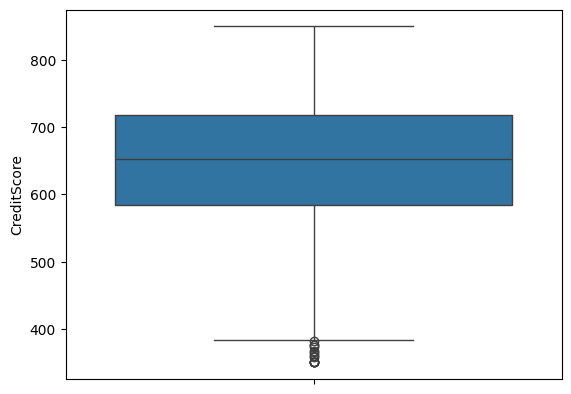

In [39]:
sns.boxplot(df["CreditScore"])

In [40]:
df["CreditScore"].mean()

np.float64(650.5644)

In [41]:
df["CreditScore"].median()

np.float64(652.0)

In [42]:
df["CreditScore"].fillna(df["CreditScore"].mode()[0],inplace=True)

In [43]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             1
Balance            2
NumOfProducts      1
HasCrCard          0
IsActiveMember     1
EstimatedSalary    0
Exited             0
dtype: int64

In [44]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1.0,15634602,Hargrave,619.0,France,Female,42,2.0,0.00,1.0,1,1.0,101348.88,1.0
1,2.0,15647311,Hill,608.0,Spain,Female,41,1.0,83807.86,1.0,0,1.0,112542.58,0.0
2,3.0,15619304,Onio,502.0,France,Female,42,8.0,159660.80,3.0,1,0.0,113931.57,1.0
3,4.0,15701354,Boni,699.0,France,Female,39,1.0,0.00,2.0,0,0.0,93826.63,0.0
4,5.0,15737888,Mitchell,850.0,Spain,Female,43,2.0,125510.82,1.0,1,1.0,79084.10,0.0


In [45]:
df["Tenure"].value_counts()

Tenure
2.0     1048
1.0     1035
7.0     1028
8.0     1025
5.0     1012
3.0     1008
4.0      989
9.0      984
6.0      967
10.0     490
0.0      413
Name: count, dtype: int64

In [46]:
df["Tenure"].fillna(df["Tenure"].mode()[0],inplace=True)

In [47]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            2
NumOfProducts      1
HasCrCard          0
IsActiveMember     1
EstimatedSalary    0
Exited             0
dtype: int64

In [48]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [49]:
num_col=['CreditScore','Age','Balance','EstimatedSalary']

In [50]:
for i in df.columns:
    if i in num_col:
        df[i].fillna(df[i].mean(),inplace=True)
    else:
        df[i].fillna(df[i].mode()[0],inplace=True)

In [51]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [52]:
df.to_csv("Churn_cleaned.csv")

In [53]:
df.nunique()

RowNumber           9999
CustomerId         10000
Surname             2931
CreditScore          460
Geography              3
Gender                 2
Age                   70
Tenure                11
Balance             6382
NumOfProducts          4
HasCrCard              2
IsActiveMember         2
EstimatedSalary     9998
Exited                 2
dtype: int64

In [54]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1.0,15634602,Hargrave,619.0,France,Female,42,2.0,0.00,1.0,1,1.0,101348.88,1.0
1,2.0,15647311,Hill,608.0,Spain,Female,41,1.0,83807.86,1.0,0,1.0,112542.58,0.0
2,3.0,15619304,Onio,502.0,France,Female,42,8.0,159660.80,3.0,1,0.0,113931.57,1.0
3,4.0,15701354,Boni,699.0,France,Female,39,1.0,0.00,2.0,0,0.0,93826.63,0.0
4,5.0,15737888,Mitchell,850.0,Spain,Female,43,2.0,125510.82,1.0,1,1.0,79084.10,0.0


In [55]:
df.groupby('Gender')["Balance"].sum()

Gender
Female    3.435700e+08
Male      4.213271e+08
Name: Balance, dtype: float64

In [56]:
df.groupby('Geography')["EstimatedSalary"].sum()

Geography
France     5.009384e+08
Germany    2.536936e+08
Spain      2.462464e+08
Name: EstimatedSalary, dtype: float64

In [57]:
df.groupby('Geography')["CreditScore"].mean()

Geography
France     649.710867
Germany    651.453567
Spain      651.392165
Name: CreditScore, dtype: float64

In [58]:
df.groupby('Gender')["EstimatedSalary"].mean()

Gender
Female    100572.770037
Male       99684.451845
Name: EstimatedSalary, dtype: float64

In [59]:
df.groupby('Exited')["EstimatedSalary"].sum()

Exited
0.0    7.941928e+08
1.0    2.066856e+08
Name: EstimatedSalary, dtype: float64

In [60]:
df.groupby('NumOfProducts')["Balance"].sum()

NumOfProducts
1.0    5.011142e+08
2.0    2.380870e+08
3.0    2.007192e+07
4.0    5.623988e+06
Name: Balance, dtype: float64